#### Importing all the modules that required for this project.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#### Importing the dataset and checking first 5 rows, shape, column names dataset information, and null values.

In [ ]:
df = pd.read_csv("../data/raw/student-mat.csv", sep=';')

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

First 5 Rows
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Dataset Shape
(395, 33)

Column Names
Index(['school', 'sex', 'age', 'addr

#### Differentiate all the numerical and categorical columns

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int']).columns

print('\nCategorical Columns:')
print(categorical_cols)

print('\nNumerical Columns:')
print(numerical_cols)



Categorical Columns:
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

Numerical Columns:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='str')

Compare Numerical Columns:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='str')


#### Checking the value counts of Performance column

In [5]:
df['Performance'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

print("\nPerformance Value Counts")
print(df['Performance'].value_counts())

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


Performance Value Counts
Performance
1    265
0    130
Name: count, dtype: int64


#### Checking the correlation with heatmap, Student performance distribution, Study time vs Performance and absence vs final grade


Correlation Matrix
               school       sex       age   address   famsize   Pstatus  \
school       1.000000 -0.012286  0.377610 -0.279797  0.064866  0.045923   
sex         -0.012286  1.000000 -0.028606 -0.028504  0.089862  0.023443   
age          0.377610 -0.028606  1.000000 -0.146722  0.037847  0.029598   
address     -0.279797 -0.028504 -0.146722  1.000000  0.072472 -0.042572   
famsize      0.064866  0.089862  0.037847  0.072472  1.000000 -0.149612   
Pstatus      0.045923  0.023443  0.029598 -0.042572 -0.149612  1.000000   
Medu        -0.133333  0.078228 -0.163658  0.138804 -0.043068 -0.123565   
Fedu        -0.079807  0.034878 -0.163438  0.072178 -0.058879 -0.088730   
Mjob        -0.056670  0.191421 -0.069104  0.108818  0.071386 -0.054476   
Fjob         0.018974  0.084957 -0.035191 -0.001911 -0.084448  0.033892   
reason      -0.090010 -0.095867 -0.015337 -0.047891 -0.019212 -0.003553   
guardian     0.011109 -0.071343  0.290485 -0.044512 -0.002718 -0.108715   
trave

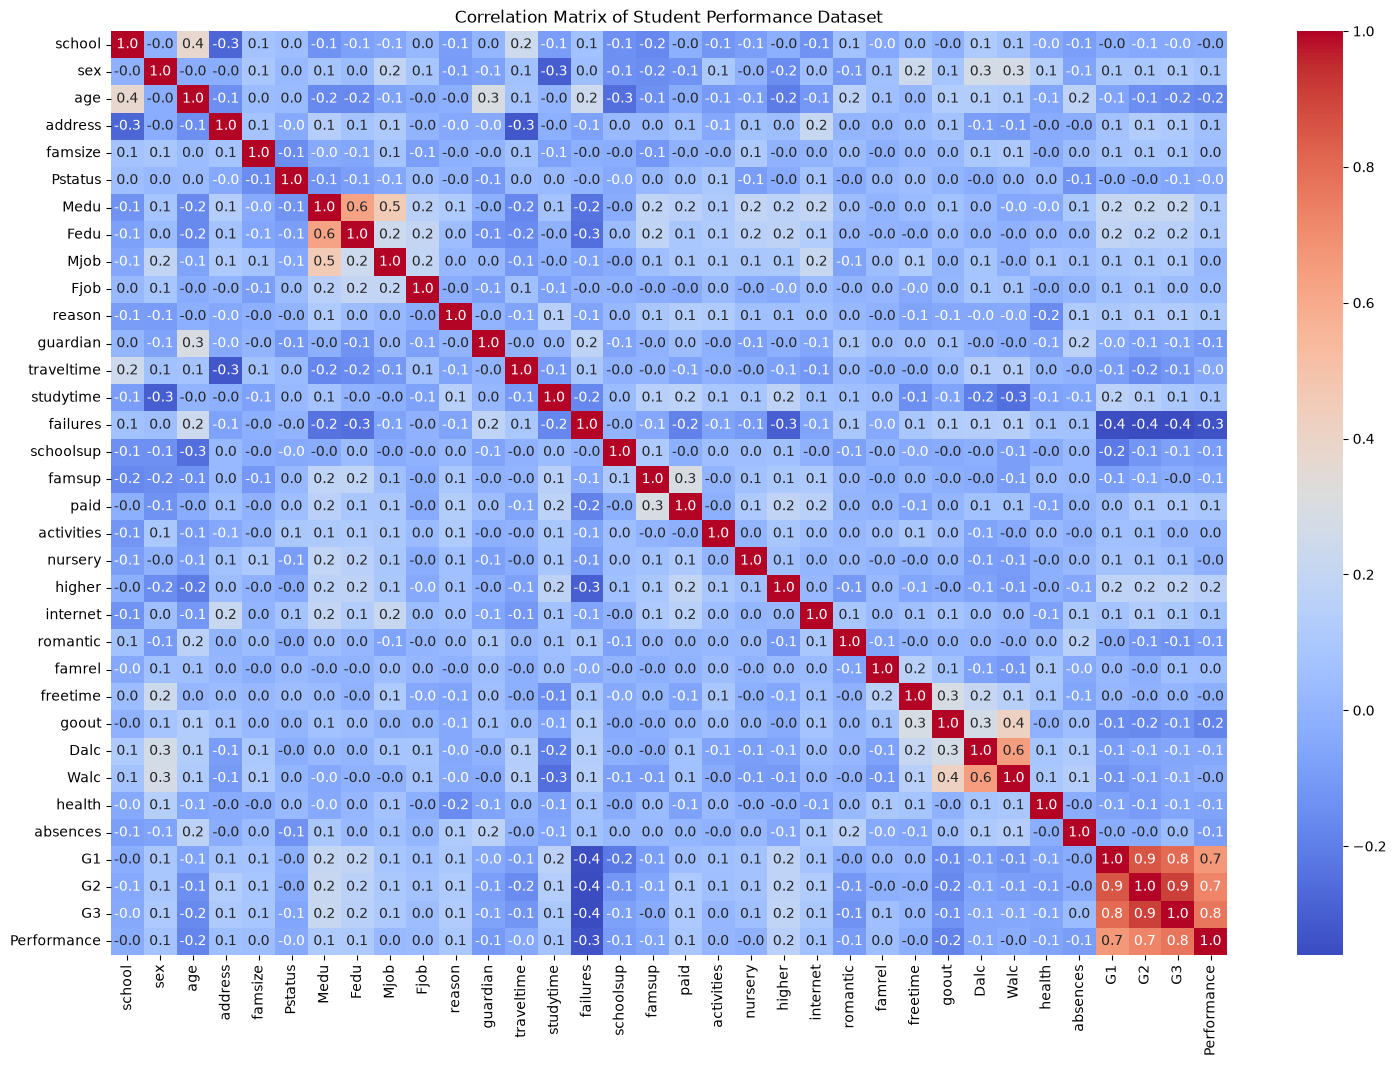

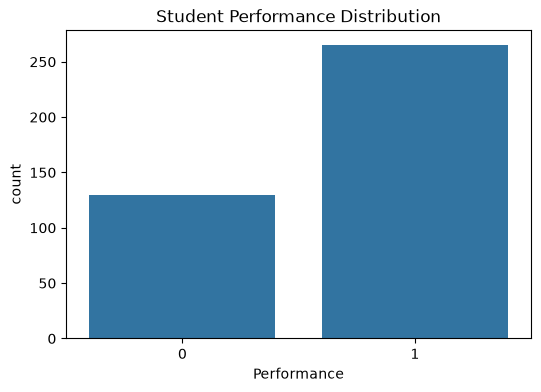

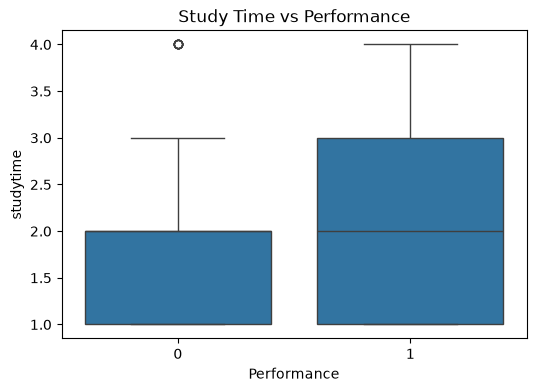

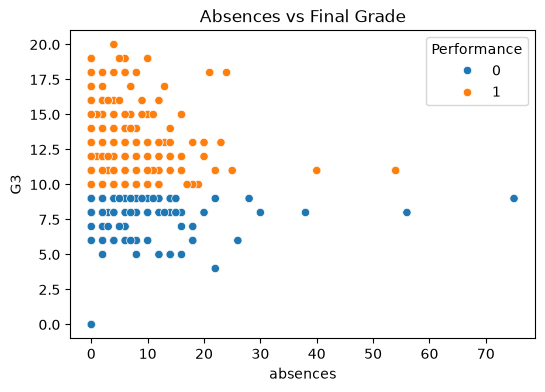

In [6]:
correlation_matrix = df.corr()

print("\nCorrelation Matrix")
print(correlation_matrix)

plt.figure(figsize=(18,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title("Correlation Matrix of Student Performance Dataset")

plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Performance', data=df)
plt.title("Student Performance Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Performance', y='studytime', data=df)
plt.title("Study Time vs Performance")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='absences', y='G3', hue='Performance', data=df)
plt.title("Absences vs Final Grade")
plt.show()


In [7]:
correlation = df.corr()['Performance'].sort_values(ascending=False)

print("\nFeatures Influencing Performance")
print(correlation)


Features Influencing Performance
Performance    1.000000
G3             0.770042
G2             0.725407
G1             0.664979
higher         0.157708
Medu           0.115396
Fedu           0.108057
reason         0.099300
paid           0.092665
studytime      0.074613
sex            0.070618
internet       0.061791
address        0.052282
famrel         0.046683
famsize        0.041842
Fjob           0.028309
Mjob           0.026592
activities     0.012414
nursery       -0.008784
freetime      -0.018321
Walc          -0.029957
school        -0.031254
Pstatus       -0.044050
traveltime    -0.044446
Dalc          -0.057343
famsup        -0.059219
health        -0.065668
absences      -0.092244
romantic      -0.097737
schoolsup     -0.099860
guardian      -0.101407
age           -0.179645
goout         -0.183399
failures      -0.337731
Name: Performance, dtype: float64


#### Featuring and Sorting the correlation w.r.t Performance in ascending order.

In [8]:
X = df.drop(['G3', 'Performance'], axis=1)

y = df['Performance']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)


Training Data Shape : (316, 32)
Testing Data Shape : (79, 32)


In [9]:
model = GaussianNB()

In [10]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nActual Values")
print(y_test.values[:20])

print("\nPredicted Values")
print(y_pred[:20])


Actual Values
[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0]

Predicted Values
[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 1]


Accuracy Score:
0.8481012658227848

 Precision Score:
0.8867924528301887

 Recall Score:
0.8867924528301887

 F1 Score:
0.8867924528301887

 Confusion Matrix:
[[20  6]
 [ 6 47]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        26
           1       0.89      0.89      0.89        53

    accuracy                           0.85        79
   macro avg       0.83      0.83      0.83        79
weighted avg       0.85      0.85      0.85        79



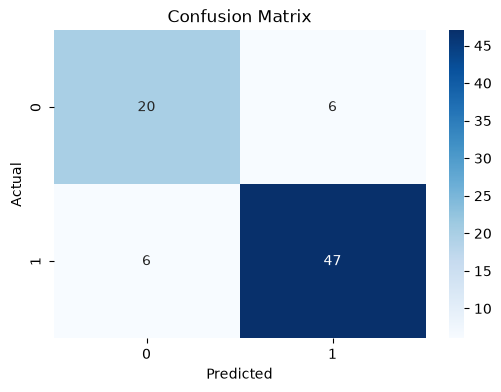

In [11]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

print("\n Precision Score:")
print(precision)

print("\n Recall Score:")
print(recall)

print("\n F1 Score:")
print(f1)

print("\n Confusion Matrix:")
print(cm)

print("\n Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")
plt.show()


In [12]:
print("\nModel Interpretation")

print("""
1. Naive Bayes predicts student performance using probability.

2. Features like study time, failures, and absences
   strongly influence student performance.

3. Higher study time generally improves performance.

4. More absences and failures reduce performance.

5. Gaussian Naive Bayes performs well for classification
   when features are conditionally independent.
""")


Model Interpretation

1. Naive Bayes predicts student performance using probability.

2. Features like study time, failures, and absences
   strongly influence student performance.

3. Higher study time generally improves performance.

4. More absences and failures reduce performance.

5. Gaussian Naive Bayes performs well for classification
   when features are conditionally independent.



In [13]:
print("\nAssumptions of Naive Bayes")

print("""
1. Features are independent of each other.

2. Numerical features follow Gaussian distribution.

3. Each feature contributes independently to prediction.
""")


Assumptions of Naive Bayes

1. Features are independent of each other.

2. Numerical features follow Gaussian distribution.

3. Each feature contributes independently to prediction.



In [20]:
print("\nWhere Naive Bayes Works Well")

print("""
1. Small and medium datasets

2. Fast prediction problems

3. Text and classification problems

4. Independent feature datasets
""")

print("\nWhere Naive Bayes May Fail")

print("""
1. Highly correlated features

2. Complex relationships between variables

3. Non-Gaussian distributed data

4. Imbalanced datasets
""")


Where Naive Bayes Works Well

1. Small and medium datasets

2. Fast prediction problems

3. Text and classification problems

4. Independent feature datasets


Where Naive Bayes May Fail

1. Highly correlated features

2. Complex relationships between variables

3. Non-Gaussian distributed data

4. Imbalanced datasets

